<a href="https://colab.research.google.com/github/G1gg1l3ws/tc-20262-g1gg1l3ws/blob/main/Automata_lib_aula_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
!apt install python3-dev graphviz libgraphviz-dev pkg-config
!pip install pygraphviz
!pip install automata-lib[visual]==9.0.0
!git clone https://github.com/TC-Rep/TCUtil.git
from TCUtil.util import validate_string, print_rastreamento_dfa

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
python3-dev is already the newest version (3.12.3-0ubuntu2.1).
graphviz is already the newest version (2.42.2-9ubuntu0.1).
libgraphviz-dev is already the newest version (2.42.2-9ubuntu0.1).
pkg-config is already the newest version (1.8.1-2build1).
0 upgraded, 0 newly installed, 0 to remove and 0 not upgraded.
fatal: destination path 'TCUtil' already exists and is not an empty directory.


In [ ]:
from automata.fa.dfa import DFA
from automata.fa.nfa import NFA

---
## 1. Modelando um AFD
Lembre-se da definição formal de um AFD como uma 5-tupla $(Q, \Sigma, \delta, q_0, F)$:
* $Q$: Conjunto de estados
* $\Sigma$: Alfabeto de entrada
* $\delta$: Função de transição ($Q \times \Sigma \to Q$)
* $q_0$: Estado inicial
* $F$: Conjunto de estados finais

### Exemplo:
Linguagem $L_1$ sobre $\Sigma = \{0, 1\}$: **Cadeias que possuem um número par de zeros**.

Dando print no objeto: 
 DFA(states={'q_impar', 'q_par'}, input_symbols={'1', '0'}, transitions={'q_par': {'0': 'q_impar', '1': 'q_par'}, 'q_impar': {'0': 'q_par', '1': 'q_impar'}}, initial_state='q_par', final_states={'q_par'}, allow_partial=False)

Dando print no type do objeto: 
 <class 'automata.fa.dfa.DFA'>


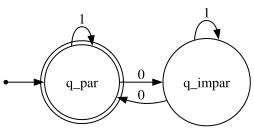

In [ ]:
afd_par_zeros = DFA(
    states={'q_par', 'q_impar'},
    input_symbols={'0', '1'},
    transitions={
        'q_par':   {'0': 'q_impar', '1': 'q_par'},
        'q_impar': {'0': 'q_par',   '1': 'q_impar'}
    },
    initial_state='q_par',
    final_states={'q_par'}
)

# Visualizando o AFD
print(f"Dando print no objeto: \n",afd_par_zeros)
print(f"\nDando print no type do objeto: \n",type(afd_par_zeros))
afd_par_zeros.show_diagram()


In [ ]:

# Testando aceitação/rejeição simples (retorna booleano)
testes_afd = ['0', '1', '00', '101', '1001', '000']

print("\n--- Testes de Aceitação no AFD ---")
for w in testes_afd:
    resultado = afd_par_zeros.accepts_input(w)
    status = "ACEITO" if resultado else "REJEITADO"
    print(f"String: '{w:<5}' -> {status}")


--- Testes de Aceitação no AFD ---
String: '0    ' -> REJEITADO
String: '1    ' -> ACEITO
String: '00   ' -> ACEITO
String: '101  ' -> REJEITADO
String: '1001 ' -> ACEITO
String: '000  ' -> REJEITADO


### Visualizando o rastreamento
Podemos acompanhar passo a passo a sequência de estados visitados durante a leitura da cadeia:

In [ ]:
cadeia_analise = '1001'
print(f"Rastreando o processamento de: '{cadeia_analise}'")

# read_input_stepwise produz um gerador com os estados sucessivos
passos = list(afd_par_zeros.read_input_stepwise(cadeia_analise))

for i, estado in enumerate(passos):
    if i == 0:
        print(f"Início:        {estado}")
    else:
        simbolo = cadeia_analise[i - 1]
        print(f"Lendo '{simbolo}':    -> {estado}")

Rastreando o processamento de: '1001'
Início:        q_par
Lendo '1':    -> q_par
Lendo '0':    -> q_impar
Lendo '0':    -> q_par
Lendo '1':    -> q_par


## Construção Automática de AFDs: Prefixos, Sufixos e Substrings

A classe `DFA` do `automata-lib` disponibiliza métodos construtores prontos para as três operações clássicas de busca e casamento de padrões em cadeias.

Esses métodos geram diretamente o autômato determinístico correspondente, calculando automaticamente todos os estados de desvio, retrocessos e laços necessários sobre o alfabeto informado.

---

### 1. Prefixo (`DFA.from_prefix`)
Reconhece apenas as cadeias que **começam** com a sequência indicada (formalmente: $L = \{ wx \mid x \in \Sigma^* \}$, onde $w$ é o prefixo alvo).

### 2. Sufixo (`DFA.from_suffix`)
Reconhece apenas as cadeias que **terminam** com a sequência indicada (formalmente: $L = \{ xw \mid x \in \Sigma^* \}$, onde $w$ é o sufixo alvo).

### 2. Substring (`DFA.from_substring`)
Reconhece qualquer cadeia que contenha a sequência indicada em qualquer posição(formalmente: $L = \{ xwy \mid x, y \in \Sigma^* \}$, onde $w$ é a subpalavra alvo).

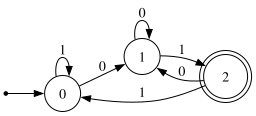

In [ ]:
afd_sufixo_01 = DFA.from_suffix({'0','1'},'01')
afd_sufixo_01.show_diagram()

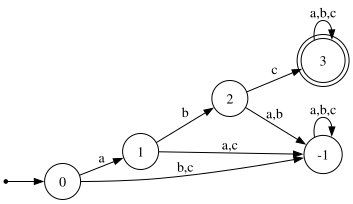

In [ ]:
afd_prefixo_abc = DFA.from_prefix({'a','b','c'},'abc',as_partial=False)
afd_prefixo_abc.show_diagram()

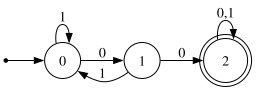

In [ ]:
afd_substring_00 = DFA.from_substring({'0','1'},'00')
afd_substring_00.show_diagram()

---
## 2. Modelando um AFN
No AFN, as principais diferenças sintáticas na biblioteca são:
1. **Múltiplos destinos:** A função $\delta$ mapeia para um **conjunto** de estados (`{'q0', 'q1'}`).
2. **Transições-$\varepsilon$:** Representadas pela cadeia vazia `''`.

### Exemplo:
Linguagem $L_2$ sobre $\Sigma = \{0, 1\}$: **Cadeias que terminam com o sufixo `01`**.

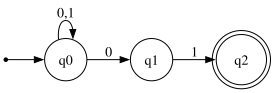

In [ ]:
afn_termina_01 = NFA(
    states={'q0', 'q1', 'q2'},
    input_symbols={'0', '1'},
    transitions={
        'q0': {'0': {'q0', 'q1'}, '1': {'q0'}},  # '0' pode manter em q0 ou bifurcar para q1
        'q1': {'1': {'q2'}},
        'q2': {}
    },
    initial_state='q0',
    final_states={'q2'}
)

afn_termina_01.show_diagram()



In [ ]:
testes_afn = ['01', '101', '00101', '10', '0010']

print("--- Teste de Aceitação no AFN ---")
for w in testes_afn:
    resultado = afn_termina_01.accepts_input(w)
    status = "ACEITO" if resultado else "REJEITADO"
    print(f"String: '{w:<5}' -> {status}")

--- Teste de Aceitação no AFN ---
String: '01   ' -> ACEITO
String: '101  ' -> ACEITO
String: '00101' -> ACEITO
String: '10   ' -> REJEITADO
String: '0010 ' -> REJEITADO


---
## 3. Conversão de AFN para AFD (Construção do Subconjunto)
Pelo Teorema da Equivalência, todo AFN possui um AFD equivalente.
A função `DFA.from_nfa(...)` executa automaticamente o algoritmo de determinização.

Estados gerados pelo algoritmo do subconjunto:
frozenset({0, 1, 2})

Tabela de Transições do AFD equivalente:
frozendict.frozendict({0: frozendict.frozendict({'0': 2, '1': 0}), 1: frozendict.frozendict({'0': 2, '1': 0}), 2: frozendict.frozendict({'0': 2, '1': 1})})

Estados de aceitação finais:
frozenset({1})


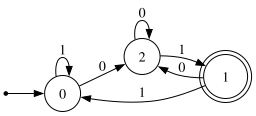

In [ ]:
# Convertendo o AFN para AFD
afd_equivalente = DFA.from_nfa(afn_termina_01)

print("Estados gerados pelo algoritmo do subconjunto:")
print(afd_equivalente.states)

print("\nTabela de Transições do AFD equivalente:")
print(afd_equivalente.transitions)

print("\nEstados de aceitação finais:")
print(afd_equivalente.final_states)

afd_equivalente.show_diagram()


In [ ]:
# 1. Teste amostral com conjunto de cadeias
amostras = ['', '0', '1', '01', '101', '1101', '0000', '0101']
print("Verificando se AFN e AFD concordam em todas as entradas:")
for w in amostras:
    assert afn_termina_01.accepts_input(w) == afd_equivalente.accepts_input(w)
    print(f"Cadeia '{w:<5}' -> AFN: {afn_termina_01.accepts_input(w)} | AFD: {afd_equivalente.accepts_input(w)}")

# 2. Teste de equivalência de linguagens formais (sobrecarga de operador ==)
print("\nO AFD gerado é formalmente equivalente ao AFN?")
print(afd_equivalente == DFA.from_nfa(afn_termina_01))

Verificando se AFN e AFD concordam em todas as entradas:
Cadeia '     ' -> AFN: False | AFD: False
Cadeia '0    ' -> AFN: False | AFD: False
Cadeia '1    ' -> AFN: False | AFD: False
Cadeia '01   ' -> AFN: True | AFD: True
Cadeia '101  ' -> AFN: True | AFD: True
Cadeia '1101 ' -> AFN: True | AFD: True
Cadeia '0000 ' -> AFN: False | AFD: False
Cadeia '0101 ' -> AFN: True | AFD: True

O AFD gerado é formalmente equivalente ao AFN?
True


---
## Exercício Prático

1. **Modelagem:** Crie um AFN que reconheça cadeias sobre $\Sigma = \{a, b\}$ que contenham a substring `aba`.
2. **Conversão:** Utilize `DFA.from_nfa(...)` para gerar o AFD correspondente.
3. **Validação:** Crie pelo menos 4 testes de cadeias (2 que pertençam à linguagem e 2 que não pertençam) e verifique se ambos os modelos produzem a mesma resposta.

Cadeia 'ababa  ' -> AFN: True | AFD: True
Cadeia 'aba    ' -> AFN: True | AFD: True
Cadeia 'ab     ' -> AFN: False | AFD: False
Cadeia 'babbab ' -> AFN: False | AFD: False
Cadeia 'aaaaaba' -> AFN: True | AFD: True
Cadeia 'abbbbba' -> AFN: False | AFD: False

O AFD gerado é formalmente equivalente ao AFN?
True


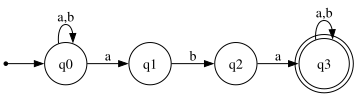

In [33]:
afn = NFA(
    states={'q0', 'q1', 'q2', 'q3'},
    input_symbols={'a', 'b'},
    transitions={
        'q0': {'a': {'q0', 'q1'}, 'b': {'q0'}},
        'q1': {'b': {'q2'}},
        'q2': {'a': {'q3'}},
        'q3': {'a': {'q3'}, 'b': {'q3'}},
    },
    initial_state='q0',
    final_states={'q3'}
    )

afd = DFA.from_nfa(afn)

strings = ['ababa', 'aba', 'ab', 'babbab', 'aaaaaba', 'abbbbba']

for s in strings:

  assert afn.accepts_input(s) == afd.accepts_input(s)
  print(f"Cadeia '{s:<7}' -> AFN: {afn.accepts_input(s)} | AFD: {afd.accepts_input(s)}")

print("\nO AFD gerado é formalmente equivalente ao AFN?")
print(afd == DFA.from_nfa(afn))
afn.show_diagram()